In [1]:
tr_path='covid.train.csv'
tt_path='covid.test.shuffle.csv'

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader

import numpy as np
import csv
import os

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

myseed=42069
torch.backends.cudnn.deterministic=True
torch.backends.cudnn.benchmark=False
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

In [3]:
def get_device():
    return 'cuda' if torch.cuda.is_available() else 'cpu'

def plot_learning_curve(loss_record,title=''):
    total_steps=len(loss_record['train'])
    x_1=range(total_steps)
    x_2=x_1[::len(loss_record['train'])//len(loss_record['dev'])]
    #//是整数除法，确保结果是整数
    figure(figsize=(6,4))
    plt.plot(x_1,loss_record['train'],c='tab:red',label='train')
    plt.plot(x_2,loss_record['dev'],c='tab:cyan',label='dev')
    plt.ylim(0.0,5.)
    plt.xlabel('Training steps')
    plt.ylabel('MSE loss')
    plt.title('Learning curve of {}'.format(title))
    plt.legend()
    plt.show()

def plot_pred(dv_set,model,device,lim=35.,preds=None,targets=None):
    if preds is None or targets is None:
        model.eval()
        preds,targets=[],[]
        for x,y in dv_set:
            x,y=x.to(device),y.to(device)
            with torch.no_grad():
                pred=model(x)
                preds.append(pred.detach().cpu())
                targets.append(y.detach().cpu())
                #detach()会从计算图分离张量，移除梯度信息
        
        preds=torch.cat(preds,dim=0).numpy()
        targets=torch.cat(targets,dim=0).numpy()
        #合并所有批次的预测值和真实值
        
    plt.figure(figsize=(5,5))
    plt.scatter(targets,preds,c='r',alpha=0.5)
    plt.plot([-0.2,lim],[-0.2,lim],c='b')
    plt.xlim(-0.2,lim)
    plt.ylim(-0.2,lim)
    plt.xlabel('ground truth value')
    plt.ylabel('predicted value')
    plt.title('Ground Truth v.s. Prediction')
    plt.show()

In [4]:
class COVID19Dataset(Dataset):
    ''' Dataset for loading and preprocessing the COVID19 dataset '''
    def __init__(self,
                 path,
                 mode='train',
                 target_only=False):
        self.mode = mode

        # Read data into numpy arrays
        with open(path, 'r') as fp:
            data = list(csv.reader(fp))
            data = np.array(data[1:])[:, 1:].astype(float)

        if not target_only:#表示是否选取特征
            feats = list(range(93))
        else:
            # TODO: Using 40 states & 2 tested_positive features (indices = 57 & 75)
            feats=list(range(40))+[57,75]
            pass
            
        if mode=='test':
            data=data[:,feats]
            self.data=torch.FloatTensor(data)
        else:
            target=data[:,-1]
            data=data[:,feats]

            if mode=='train':
                indices=[i for i in range(len(data)) if i % 10 !=0]
            elif mode=='dev':
                indices=[i for i in range(len(data)) if i % 10 ==0]
                
            self.data=torch.FloatTensor(data[indices])
            self.target=torch.FloatTensor(target[indices])
        #正则化
        self.data[:,40:]=\
        (self.data[:,40:]-self.data[:,40:].mean(dim=0,keepdim=True))\
        /self.data[:,40:].std(dim=0,keepdim=True)

        self.dim=self.data.shape[1]
        print('Finished reading the {} set of COVID19 Dataset' 
        '({} samples found,each dim={})'.format(mode,len(self.data),self.dim))

    def __getitem__(self,index):
        if self.mode in ['train','dev']:
            return self.data[index],self.target[index]
        else:
            return self.data[index]

    def __len__(self):
        return len(self.data)



In [5]:
def prep_dataloader(path,mode,batch_size,n_jobs=0,target_only=False):
    dataset=COVID19Dataset(path,mode=mode,target_only=target_only)
    dataloader=DataLoader(
        dataset,
        batch_size,
        shuffle=(mode=='train'),drop_last=False,
        num_workers=n_jobs,pin_memory=True)
    return dataloader

In [6]:
class NeuralNet(nn.Module):
    def __init__(self,input_dim):
        super(NeuralNet,self).__init__()

        self.net=nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,1)
        )
        self.criterion=nn.MSELoss(reduction='mean')
    def forward(self,x):
        return self.net(x).squeeze(1)
    def cal_loss(self,pred,target):
        return self.criterion(pred,target)

In [7]:
def train(tr_set,dv_set,model,config,device):
    n_epochs=config['n_epochs']#最大训练轮数！
    #初始化优化器
    optimizer=getattr(torch.optim,config['optimizer'])(
        model.parameters(),**config['optim_hparas']
    )#！
    min_mse=1000.
    loss_record={'train':[],'dev':[]}
    early_stop_cnt=0#早停计数器
    epoch=0
    while epoch<n_epochs:
        model.train()#！
        for x,y in tr_set:
            optimizer.zero_grad()
            x,y=x.to(device),y.to(device)
            pred=model(x)
            mse_loss=model.cal_loss(pred,y)
            mse_loss.backward()
            optimizer.step()
            loss_record['train'].append(mse_loss.detach().cpu().item())

        dev_mse=dev(dv_set,model,device)
        
        if dev_mse<min_mse:
            min_mse=dev_mse
            print('Saving model (epoch={:4d},loss={:.4f})'
                 .format(epoch+1,min_mse))
            torch.save(model.state_dict(),config['save_path'])
            early_stop_cnt=0
        else:
            early_stop_cnt+=1
        epoch+=1
        loss_record['dev'].append(dev_mse)
        if early_stop_cnt>config['early_stop']:
            break
    print('Finished training after {} epochs'.format(epoch))
    return min_mse,loss_record

In [20]:
def dev(dv_set,model,device):
    model.eval()
    total_loss=0
    for x,y in dv_set:
        x,y=x.to(device),y.to(device)
        with torch.no_grad():
            pred=model(x)
            mse_loss=model.cal_loss(pred,y)
        total_loss+=mse_loss.detach().cpu().item()*len(x)
    total_loss=total_loss/len(dv_set.dataset)
    return total_loss

In [29]:
def test(tt_set,model,device):
    model.eval()
    preds=[]
    for x in tt_set:
        x=x.to(device)
        with torch.no_grad():
            pred=model(x)
            preds.append(pred.detach().cpu())
    preds=torch.cat(preds,dim=0).numpy()
    return preds

In [22]:
device=get_device()
os.makedirs('models',exist_ok=True)
target_only=False
config={
    'n_epochs':3000,
    'batch_size':270,
    'optimizer':'SGD',
    'optim_hparas':{
        'lr':0.01,
        'momentum':0.9
    },
    'early_stop':200,
    'save_path':'models/model.pth'
}

In [23]:
tr_set=prep_dataloader(tr_path,'train',config['batch_size'],target_only=target_only)
dv_set=prep_dataloader(tr_path,'dev',config['batch_size'],target_only=target_only)
tt_set=prep_dataloader(tt_path,'test',config['batch_size'],target_only=target_only)

Finished reading the train set of COVID19 Dataset(2430 samples found,each dim=93)
Finished reading the dev set of COVID19 Dataset(270 samples found,each dim=93)
Finished reading the test set of COVID19 Dataset(893 samples found,each dim=93)


In [24]:
model=NeuralNet(tr_set.dataset.dim).to(device)

In [25]:
model_loss,model_loss_record=train(tr_set,dv_set,model,config,device)

Saving model (epoch=   1,loss=50.1273)
Saving model (epoch=   2,loss=21.5841)
Saving model (epoch=   3,loss=7.6416)
Saving model (epoch=   4,loss=4.9746)
Saving model (epoch=   6,loss=3.4958)
Saving model (epoch=   7,loss=2.1104)
Saving model (epoch=   8,loss=1.7764)
Saving model (epoch=   9,loss=1.6799)
Saving model (epoch=  10,loss=1.4963)
Saving model (epoch=  11,loss=1.2971)
Saving model (epoch=  12,loss=1.2555)
Saving model (epoch=  15,loss=1.2486)
Saving model (epoch=  17,loss=1.0831)
Saving model (epoch=  19,loss=1.0219)
Saving model (epoch=  20,loss=1.0171)
Saving model (epoch=  23,loss=0.9944)
Saving model (epoch=  28,loss=0.9879)
Saving model (epoch=  29,loss=0.9777)
Saving model (epoch=  35,loss=0.9633)
Saving model (epoch=  37,loss=0.9049)
Saving model (epoch=  42,loss=0.8509)
Saving model (epoch=  50,loss=0.8445)
Saving model (epoch=  57,loss=0.8246)
Saving model (epoch=  75,loss=0.8210)
Saving model (epoch=  91,loss=0.8130)
Saving model (epoch= 109,loss=0.7777)
Saving mod

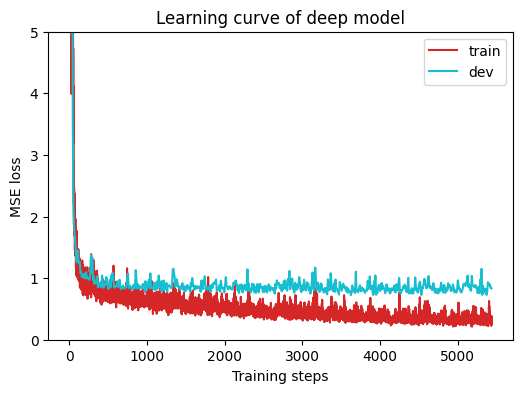

In [26]:
plot_learning_curve(model_loss_record,title='deep model')

C:\Users\Along\AppData\Local\Temp\ipykernel_2324\1519422776.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt=torch.load(config['save_path'],map_location='cpu')


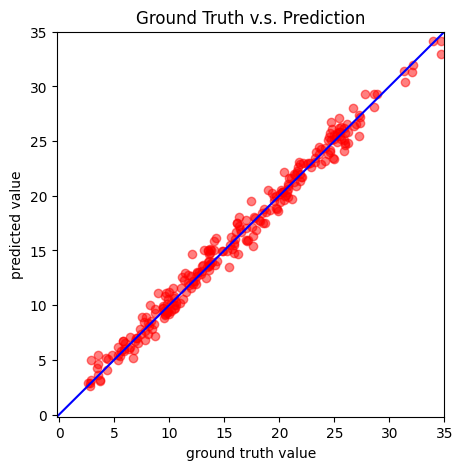

In [27]:
del model
model=NeuralNet(tr_set.dataset.dim).to(device)
ckpt=torch.load(config['save_path'],map_location='cpu')
model.load_state_dict(ckpt)
plot_pred(dv_set,model,device)

In [30]:
def save_pred(preds,file):
    print('Saving results to {}'.format(file))
    with open(file,'w') as fp:
        writer=csv.writer(fp)
        writer.writerow(['id','tested_positive'])
        for i,p in enumerate(preds):
            writer.writerow([i,p])
preds=test(tt_set,model,device)
save_pred(preds,'pred.csv')

Saving results to pred.csv
